1. Preparación del entorno

In [9]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data = load_breast_cancer()
X = data.data
y = data.target

print("Shape de X:", X.shape)
print("Clases:", data.target_names)  # ['malignant' 0, 'benign' 1]

Shape de X: (569, 30)
Clases: ['malignant' 'benign']


2. División y escalado

In [10]:
# Split 80% train - 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar (solo con datos de entrenamiento)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

3. SVM

*   Linear
*   Polynomial (degree=3)
*   RBF (Radial Basis Function)
*   Sigmoid




In [11]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results_svm = []

for kernel in kernels:
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=3, random_state=42)
    else:
        model = SVC(kernel=kernel, random_state=42)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_svm.append({
        'Kernel': kernel,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4)
    })

# Mostrar resultados SVM
df_svm = pd.DataFrame(results_svm)
print(df_svm)

    Kernel  Accuracy  Precision  Recall  F1-score
0   linear    0.9561     0.9714  0.9577    0.9645
1     poly    0.8684     0.8256  1.0000    0.9045
2      rbf    0.9825     0.9726  1.0000    0.9861
3  sigmoid    0.9561     0.9459  0.9859    0.9655


Para este dataset:

Analizando a partir de la F1-score, RBF en este caso es el mejor de los modelos . Linear y sigmoid también arrojaron buenos resultados. Polynomial fue el que dejo peores resultados.

Analizando a partir del contexto, en este caso al ser el problema sobre el diagnostico de una enfermedad, se entiende que es preferible que el modelo sea capaz de detectar la mayor cantidad de casos positivos posibles, incluso si se aumenta el riesgo de aumentar la cantidad de falsos positivos. Por tanto, lo más crítico es maximizar la precision del modelo, es decir, detectar la mayor cantidad posible de casos reales de cáncer (minimizar falsos negativos). En este caso el mejor sigue siendo RBF, que presenta un valor de precision muy alto, manteniendo también muy buena accuracy general.

In [12]:
# Métricas con malignant (clase 0) como positivo
prec = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
rec  = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
f1   = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

4. Experimentos con MLP

*   1 hidden layer con 64 neuronas→ hidden_layer_sizes=(64,)
*   2 hidden layers con 64 neuronas cada una→ (64, 64)
*   3 hidden layers → (64, 64, 64)
*   4 hidden layers → (64, 64, 64, 64)

In [13]:
mlp_configs = [
    (64,),          # 1 capa
    (64, 64),       # 2 capas
    (64, 64, 64),   # 3 capas
    (64, 64, 64, 64) # 4 capas
]

results_mlp = []

for config in mlp_configs:
    model = MLPClassifier(
        hidden_layer_sizes=config,
        max_iter=1000,
        random_state=42,
        solver='adam',
        alpha=0.0001   # regularización ligera
    )

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_mlp.append({
        'Arquitectura': f"{len(config)} hidden layers {config}",
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4)
    })

df_mlp = pd.DataFrame(results_mlp)
print(df_mlp)

                       Arquitectura  Accuracy  Precision  Recall  F1-score
0             1 hidden layers (64,)    0.9737     0.9722  0.9859    0.9790
1          2 hidden layers (64, 64)    0.9649     0.9718  0.9718    0.9718
2      3 hidden layers (64, 64, 64)    0.9737     0.9722  0.9859    0.9790
3  4 hidden layers (64, 64, 64, 64)    0.9737     0.9722  0.9859    0.9790


5. Tabla Comparativa Final

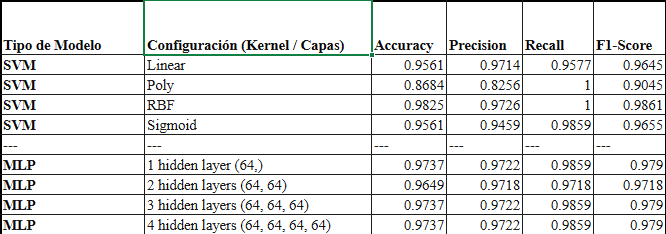

El mejor modelo considerando el contexto médico es:
SVM con kernel RBF. Este modelo empata con SVM Linear en Precision, pero el resto de las metricas son superiores. Logra el mejor F1-score. Detecta correctamente el 97.26% de los casos reales de cáncer.

Todos los modelos de MLP tienen una precision ligeramente más bajo que el mejor SVM pero en general se comportan mejor en cuanto a la precision. Se puede observar que, en este caso, aumentar el número de capas ocultas en el MLP no mejoró el rendimiento, que incluso se mantuvo igual o ligeramente peor, lo cual es común en datasets pequeños como este.

Gráfico de barras agrupadas para la precisión

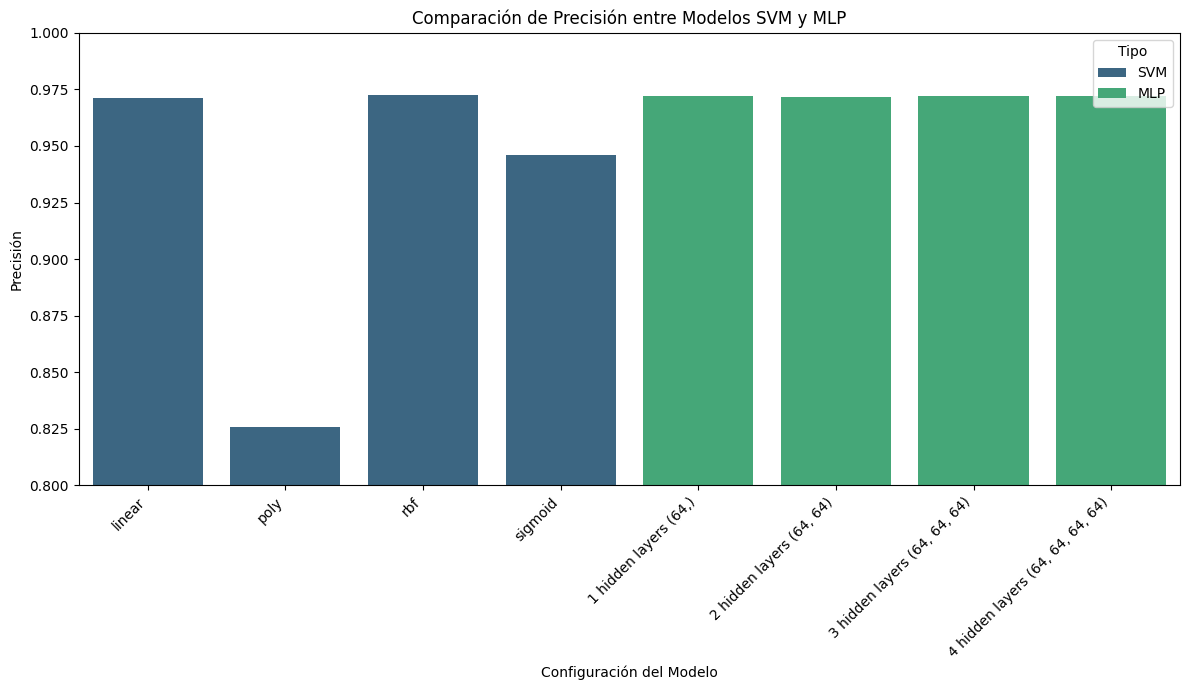

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

df_svm['Tipo'] = 'SVM'
df_mlp['Tipo'] = 'MLP'

df_svm_renamed = df_svm.rename(columns={'Kernel': 'Configuración'})
df_mlp_renamed = df_mlp.rename(columns={'Arquitectura': 'Configuración'})

# Limpiar el nombre de la configuración en df_mlp_renamed
df_mlp_renamed['Configuración'] = df_mlp_renamed['Configuración'].apply(lambda x: x.split('(')[0].strip() + ' (' + x.split('(')[1].split(')')[0] + ')')


df_combined = pd.concat([df_svm_renamed, df_mlp_renamed], ignore_index=True)

plt.figure(figsize=(12, 7))
sns.barplot(x='Configuración', y='Precision', hue='Tipo', data=df_combined, palette='viridis')
plt.title('Comparación de Precisión entre Modelos SVM y MLP')
plt.xlabel('Configuración del Modelo')
plt.ylabel('Precisión')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

Matrices de Confusión para los mejores modelos



Los mejores modelos en este caso son el SVM (RBF) por ser el que mejores metricas presenta. Mientras que el mejor modelo de Red Neuronal es el de una sola capa, porque a pesar de que sus metricas so iguales que las de otros modelos, es el mas sencillo de implementar computacionalmente.

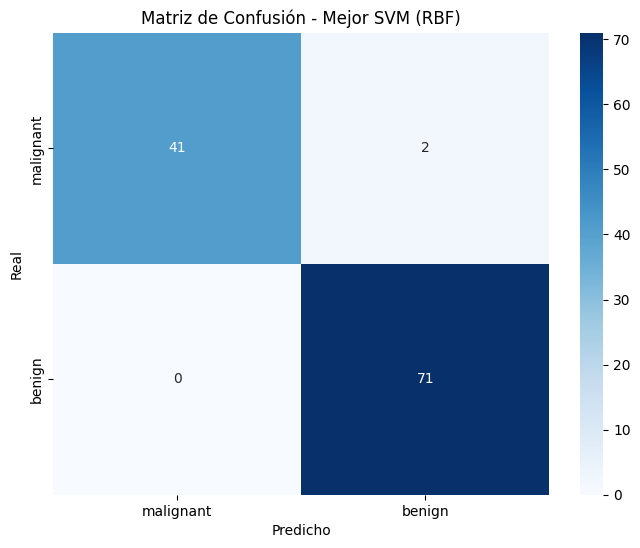

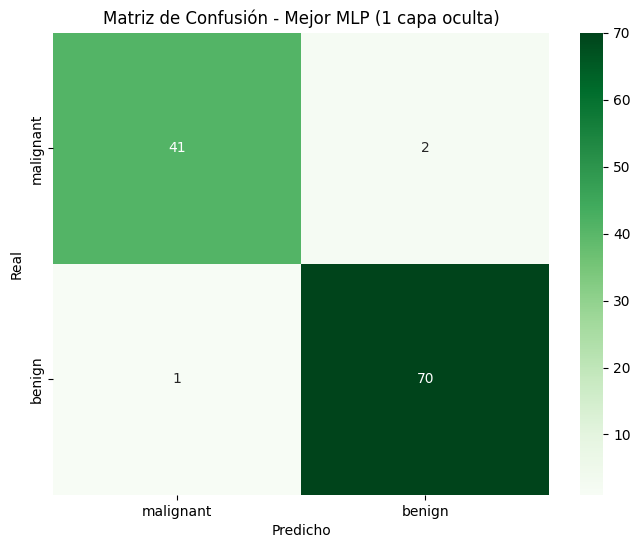

In [19]:
# Matriz de Confusión para el mejor SVM (RBF)
model_svm_best = SVC(kernel='rbf', random_state=42)
model_svm_best.fit(X_train_scaled, y_train)
y_pred_svm_best = model_svm_best.predict(X_test_scaled)

cm_svm_best = confusion_matrix(y_test, y_pred_svm_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matriz de Confusión - Mejor SVM (RBF)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Matriz de Confusión para el mejor MLP (1 capa oculta)
model_mlp_best = MLPClassifier(
    hidden_layer_sizes=(64,),
    max_iter=1000,
    random_state=42,
    solver='adam',
    alpha=0.0001
)
model_mlp_best.fit(X_train_scaled, y_train)
y_pred_mlp_best = model_mlp_best.predict(X_test_scaled)

cm_mlp_best = confusion_matrix(y_test, y_pred_mlp_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matriz de Confusión - Mejor MLP (1 capa oculta)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()